In [1]:
!pip install torchprofile 1>/dev/null

# Setup

In [2]:
# @title ## 1. Setup (Imports, Model, Data, Helpers)
# Import necessary libraries (combined from Lab0 and Lab1)
import copy
import math
import random
import time
from collections import OrderedDict, defaultdict
from typing import Union, List
import os
import sys
import ssl
from urllib.request import urlretrieve

import numpy as np
import torch
from matplotlib import pyplot as plt
from torch import nn
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader
from torchprofile import profile_macs
from torchvision.datasets import *
from torchvision.transforms import *
from tqdm.auto import tqdm

In [3]:
# Ensure CUDA is available
# assert torch.cuda.is_available(), \
#     "CUDA not available. Please connect to a GPU runtime (Runtime -> Change runtime type)."
# Use CPU if CUDA not available for broader compatibility, though slower.
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using GPU.")
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU. This will be significantly slower.")

# --- Seed Control (from Lab0) ---
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

CUDA is available. Using GPU.


In [4]:
# --- Model Definition (VGG from Lab0/Lab1) ---
class VGG(nn.Module):
  ARCH = [64, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

  def __init__(self) -> None:
    super().__init__()
    layers = []
    counts = defaultdict(int)

    def add(name: str, layer: nn.Module) -> None:
      layers.append((f"{name}{counts[name]}", layer))
      counts[name] += 1

    in_channels = 3
    for x in self.ARCH:
      if x != 'M':
        add("conv", nn.Conv2d(in_channels, x, 3, padding=1, bias=False))
        add("bn", nn.BatchNorm2d(x))
        add("relu", nn.ReLU(True))
        in_channels = x
      else:
        add("pool", nn.MaxPool2d(2))

    self.backbone = nn.Sequential(OrderedDict(layers))
    self.classifier = nn.Linear(512, 10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.backbone(x)
    x = x.mean([2, 3]) # avgpool
    x = self.classifier(x)
    return x

In [5]:
# --- Download Utility (from Lab1) ---
def download_url(url, model_dir='.', overwrite=False):
    ssl._create_default_https_context = ssl._create_unverified_context
    target_dir = url.split('/')[-1]
    model_dir = os.path.expanduser(model_dir)
    try:
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)
        model_dir = os.path.join(model_dir, target_dir)
        cached_file = model_dir
        if not os.path.exists(cached_file) or overwrite:
            sys.stderr.write('Downloading: "{}" to {}\n'.format(url, cached_file))
            urlretrieve(url, cached_file)
        return cached_file
    except Exception as e:
        # remove lock file so download can be executed next time.
        # os.remove(os.path.join(model_dir, 'download.lock')) # Might cause issues if lock file doesn't exist
        sys.stderr.write('Failed to download from url %s' % url + '\n' + str(e) + '\n')
        return None

In [6]:
# --- Load Pretrained Model (from Lab1) ---
print("Loading pretrained VGG model...")
checkpoint_url = "https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth"
# Use '.' to download to the current directory
checkpoint_path = download_url(checkpoint_url, model_dir='.')
if checkpoint_path is None:
    raise RuntimeError("Failed to download checkpoint.")

checkpoint = torch.load(checkpoint_path, map_location="cpu")
model = VGG().to(device)
print(f"=> loading checkpoint '{checkpoint_url}'")
model.load_state_dict(checkpoint['state_dict'])
# Save original state for reloading
original_state_dict = copy.deepcopy(model.state_dict())
print("Model loaded.")

Loading pretrained VGG model...


Downloading: "https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth" to ./vgg.cifar.pretrained.pth


=> loading checkpoint 'https://hanlab18.mit.edu/files/course/labs/vgg.cifar.pretrained.pth'
Model loaded.


In [7]:
# --- Data Loading (CIFAR-10 from Lab0/Lab1) ---
print("Loading CIFAR-10 dataset...")
image_size = 32
transforms = {
    "train": Compose([
        RandomCrop(image_size, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
        # Add normalization used by many pretrained models
        # Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]),
    "test": Compose([
        ToTensor(),
        # Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]),
}
dataset = {}
for split in ["train", "test"]:
  dataset[split] = CIFAR10(
    root="data/cifar10",
    train=(split == "train"),
    download=True,
    transform=transforms[split],
  )
dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=512 if device.type == 'cuda' else 64, # Smaller batch for CPU
    shuffle=(split == 'train'),
    num_workers=0, # Use 2 workers for potentially faster loading
    pin_memory=True if device.type == 'cuda' else False,
  )
print("Dataset loaded.")

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [00:04<00:00, 41.3MB/s]


Dataset loaded.


In [8]:
# --- Training and Evaluation Functions (from Lab0/Lab1, adapted for device) ---
def train(
  model: nn.Module,
  dataloader: DataLoader,
  criterion: nn.Module,
  optimizer: Optimizer,
  scheduler: LambdaLR,
  callbacks = None,
  device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Added device parameter
) -> None:
  model.train()
  model.to(device) # Ensure model is on the correct device
  for inputs, targets in tqdm(dataloader, desc='train', leave=False):
    inputs = inputs.to(device)
    targets = targets.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if callbacks is not None:
        for callback in callbacks:
            callback()

@torch.inference_mode()
def evaluate(
  model: nn.Module,
  dataloader: DataLoader,
  verbose=True,
  device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Added device parameter
) -> float:
  model.eval()
  model.to(device) # Ensure model is on the correct device
  num_samples = 0
  num_correct = 0
  for inputs, targets in tqdm(dataloader, desc="eval", leave=False, disable=not verbose):
    inputs = inputs.to(device)
    targets = targets.to(device)
    outputs = model(inputs)
    outputs = outputs.argmax(dim=1)
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()
  return (num_correct / num_samples * 100).item()

# --- Helper Functions (from Lab1, adapted for device) ---
def get_model_macs(model, inputs) -> int:
    model.to(inputs.device) # Ensure model and input are on same device
    return profile_macs(model, inputs)

def get_sparsity(tensor: torch.Tensor) -> float:
    return 1 - float(tensor.count_nonzero()) / tensor.numel()

def get_model_sparsity(model: nn.Module) -> float:
    num_nonzeros, num_elements = 0, 0
    for param in model.parameters():
        num_nonzeros += param.count_nonzero()
        num_elements += param.numel()
    return 1 - float(num_nonzeros) / num_elements if num_elements > 0 else 0.0

def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
    num_counted_elements = 0
    for param in model.parameters():
        if count_nonzero_only:
             # Make sure mask is applied before counting if using this for pruned models
             num_counted_elements += param.count_nonzero()
        else:
            num_counted_elements += param.numel()
    return num_counted_elements

def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    # Ensure masks are applied for count_nonzero_only=True if needed elsewhere
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

# --- Plotting Functions (from Lab1) ---
def plot_weight_distribution(model, bins=256, count_nonzero_only=False, title_suffix=""):
    fig, axes = plt.subplots(3,3, figsize=(10, 6))
    axes = axes.ravel()
    plot_index = 0
    for name, param in model.named_parameters():
         # Only plot layers with weights (Conv, Linear)
        if param.dim() > 1 and plot_index < len(axes):
            ax = axes[plot_index]
            param_cpu = param.detach().view(-1).cpu()
            if count_nonzero_only:
                param_cpu = param_cpu[param_cpu != 0].view(-1)

            if param_cpu.numel() > 0: # Avoid error if all weights are zero
                 ax.hist(param_cpu, bins=bins, density=True, color = 'blue', alpha = 0.5)
            ax.set_xlabel(name)
            ax.set_ylabel('density')
            plot_index += 1
        elif plot_index >= len(axes):
             break # Stop plotting if we run out of axes
    # Remove empty subplots
    for i in range(plot_index, len(axes)):
        fig.delaxes(axes[i])
    fig.suptitle(f'Histogram of Weights {title_suffix}')
    fig.tight_layout()
    fig.subplots_adjust(top=0.925)
    plt.show()

def plot_sensitivity_scan(sparsities, accuracies, layer_names, dense_model_accuracy):
    lower_bound_accuracy = dense_model_accuracy * 0.95 # Example: 95% of original
    fig, axes = plt.subplots(3, int(math.ceil(len(accuracies) / 3)),figsize=(15,8))
    axes = axes.ravel()
    plot_index = 0
    num_layers_plotted = 0
    for i, name in enumerate(layer_names):
         if plot_index < len(axes): # Check if axes exist
              ax = axes[plot_index]
              curve = ax.plot(sparsities, accuracies[i]) # Use index i
              line = ax.plot(sparsities, [lower_bound_accuracy] * len(sparsities))
              ax.set_xticks(np.round(sparsities, 2)) # Use actual sparsities for ticks
              min_acc = min(min(acc_list) for acc_list in accuracies) if accuracies else 0
              max_acc = max(max(acc_list) for acc_list in accuracies) if accuracies else 100
              ax.set_ylim(max(0, min_acc - 5) , min(100, max_acc + 2)) # Dynamic Y Lim
              ax.set_title(name)
              ax.set_xlabel('Sparsity Ratio')
              ax.set_ylabel('Top-1 Accuracy (%)')
              ax.legend([
                   'Accuracy after Pruning',
                   f'{lower_bound_accuracy:.1f}% Accuracy' # Indicate absolute lower bound
              ])
              ax.grid(axis='both')
              plot_index += 1
              num_layers_plotted += 1

    # Remove empty subplots if any exist
    for i in range(num_layers_plotted, len(axes)):
        if i < len(axes): # Double check index
            fig.delaxes(axes[i])

    fig.suptitle('Sensitivity Curves: Accuracy vs. Sparsity Ratio (Per Layer)')
    fig.tight_layout()
    fig.subplots_adjust(top=0.925)
    plt.show()

# --- Measure Latency (from Lab1) ---
@torch.no_grad()
def measure_latency(model, dummy_input, n_warmup=20, n_test=100):
    model.eval()
    model.to(dummy_input.device) # Ensure model and input on same device
    # Warmup
    for _ in range(n_warmup):
        _ = model(dummy_input)
    # Use torch events for more accurate GPU timing if available
    if dummy_input.device.type == 'cuda':
        starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
        timings = np.zeros((n_test, 1))
        # Measure
        for rep in range(n_test):
            starter.record()
            _ = model(dummy_input)
            ender.record()
            # Wait for GPU sync
            torch.cuda.synchronize()
            curr_time = starter.elapsed_time(ender) # milliseconds
            timings[rep] = curr_time
        avg_latency = np.sum(timings) / n_test / 1000.0 # Convert to seconds
    else: # CPU timing
        t1 = time.time()
        for _ in range(n_test):
            _ = model(dummy_input)
        t2 = time.time()
        avg_latency = (t2 - t1) / n_test # average latency in seconds
    return avg_latency



# Evalute Pre-Trained Model

In [9]:
# --- Evaluate Original Model ---
print("Evaluating original dense model...")
dense_model_accuracy = evaluate(model, dataloader['test'], device=device)
dense_model_size = get_model_size(model)
dense_model_params = get_num_parameters(model)
print(f"Dense model accuracy = {dense_model_accuracy:.2f}%")
print(f"Dense model size = {dense_model_size / MiB:.2f} MiB")
print(f"Dense model params = {dense_model_params / 1e6:.2f} M")
print("-" * 30)

Evaluating original dense model...


eval:   0%|          | 0/20 [00:00<?, ?it/s]

Dense model accuracy = 92.95%
Dense model size = 35.20 MiB
Dense model params = 9.23 M
------------------------------


# Unstructured Pruning

In [10]:
# @title ## 2. Unstructured Pruning (Fine-grained Magnitude-based)

# --- Fine-grained Pruning Function (from Lab1) ---
def fine_grained_prune(tensor: torch.Tensor, sparsity : float) -> torch.Tensor:
    """
    magnitude-based pruning for single tensor
    :param tensor: torch.(cuda.)Tensor, weight of conv/fc layer
    :param sparsity: float, pruning sparsity (proportion of zeros)
    :return: torch.(cuda.)Tensor, binary mask (1 = keep, 0 = prune)
    """
    sparsity = min(max(0.0, sparsity), 1.0)
    if sparsity == 1.0:
        tensor.zero_()
        return torch.zeros_like(tensor, dtype=torch.bool) # Use bool for mask
    elif sparsity == 0.0:
        return torch.ones_like(tensor, dtype=torch.bool) # Use bool for mask

    num_elements = tensor.numel()
    num_zeros = round(num_elements * sparsity)

    importance = tensor.abs()
    # Handle edge case where num_zeros might be 0 after rounding
    if num_zeros <= 0:
        return torch.ones_like(tensor, dtype=torch.bool)
    # Ensure k is within valid range for kthvalue (1 to num_elements)
    k = max(1, min(num_zeros + 1, num_elements))
    threshold = torch.kthvalue(importance.view(-1), k).values # Correctly index kthvalue output
    mask = torch.gt(importance, threshold) # importance > threshold

    tensor.mul_(mask) # Apply mask in-place

    return mask.bool() # Return boolean mask

In [11]:
# --- FineGrainedPruner Class (from Lab1, stores boolean masks) ---
class FineGrainedPruner:
    def __init__(self, model, sparsity_dict):
        self.masks = FineGrainedPruner.prune(model, sparsity_dict)
        self.model = model # Store model reference to apply masks easily

    @torch.no_grad()
    def apply(self):
        # Applies the stored masks to the model's parameters in-place.
        for name, param in self.model.named_parameters():
            if name in self.masks:
                param.mul_(self.masks[name]) # Use stored boolean mask

    @staticmethod
    @torch.no_grad()
    def prune(model, sparsity_dict):
        # Generates boolean masks based on sparsity_dict and applies them once.
        masks = dict()
        for name, param in model.named_parameters():
            # Only prune Conv and Linear layers (dim > 1)
            if param.dim() > 1 and name in sparsity_dict:
                masks[name] = fine_grained_prune(param, sparsity_dict[name])
        return masks

Plotting initial weight distribution...


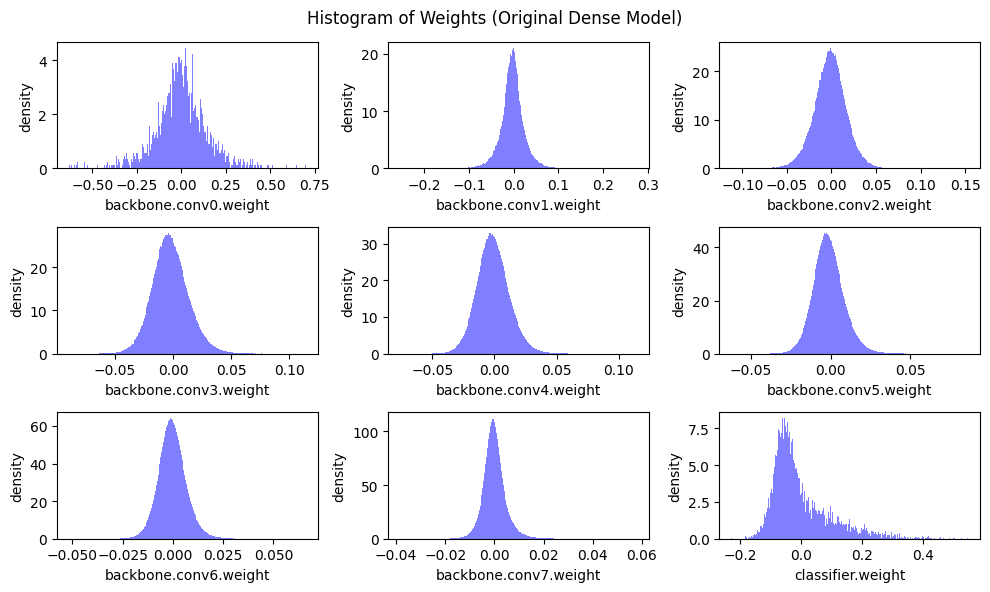


Performing sensitivity scan (this may take a few minutes)...


In [12]:
# --- 1a. Plot Initial Weight Distribution ---
print("Plotting initial weight distribution...")
plot_weight_distribution(model, title_suffix="(Original Dense Model)")

# --- 1b. Sensitivity Scan ---
print("\nPerforming sensitivity scan (this may take a few minutes)...")
# Get names of layers to be pruned
prunable_layer_names = [name for name, param in model.named_parameters() if param.dim() > 1]

In [13]:
# Define sensitivity_scan using the fine_grained_prune function
@torch.no_grad()
def sensitivity_scan(model, dataloader, scan_step=0.1, scan_start=0.1, scan_end=1.0, verbose=True, device=torch.device("cpu")):
    sparsities = np.arange(start=scan_start, stop=scan_end, step=scan_step)
    # Round sparsities for clearer plotting/reporting
    sparsities = np.round(sparsities, 2)
    accuracies = []
    # Use prunable_layer_names defined outside
    named_prunable_weights = [(name, param) for (name, param) in model.named_parameters() if name in prunable_layer_names]

    original_state = copy.deepcopy(model.state_dict()) # Save original state

    for i_layer, (name, param) in enumerate(named_prunable_weights):
        param_clone = param.detach().clone()
        accuracy = []
        print(f'Scanning {i_layer+1}/{len(named_prunable_weights)}: {name}')
        for sparsity in tqdm(sparsities, desc=f'Sparsity', leave=False):
            # Apply pruning to the parameter directly (fine_grained_prune does this in-place)
            fine_grained_prune(param, sparsity=sparsity)
            acc = evaluate(model, dataloader, verbose=False, device=device)
            # Restore the specific parameter BEFORE evaluating the next sparsity
            param.copy_(param_clone)
            accuracy.append(acc)
            if verbose:
                print(f'    Sparsity={sparsity:.2f}: Accuracy={acc:.2f}%')

        accuracies.append(accuracy)
        # Restore the entire model state after scanning a layer (optional but safer)
        # model.load_state_dict(original_state)

    # Ensure model is fully restored at the end
    model.load_state_dict(original_state)
    return sparsities, accuracies

Scanning 1/9: backbone.conv0.weight


Sparsity:   0%|          | 0/9 [00:00<?, ?it/s]

    Sparsity=0.10: Accuracy=92.93%
    Sparsity=0.20: Accuracy=92.95%
    Sparsity=0.30: Accuracy=92.63%
    Sparsity=0.40: Accuracy=92.40%
    Sparsity=0.50: Accuracy=91.18%
    Sparsity=0.60: Accuracy=87.70%
    Sparsity=0.70: Accuracy=82.34%
    Sparsity=0.80: Accuracy=69.41%
    Sparsity=0.90: Accuracy=32.83%
Scanning 2/9: backbone.conv1.weight


Sparsity:   0%|          | 0/9 [00:00<?, ?it/s]

    Sparsity=0.10: Accuracy=92.94%
    Sparsity=0.20: Accuracy=92.91%
    Sparsity=0.30: Accuracy=92.97%
    Sparsity=0.40: Accuracy=92.93%
    Sparsity=0.50: Accuracy=92.88%
    Sparsity=0.60: Accuracy=92.71%
    Sparsity=0.70: Accuracy=92.41%
    Sparsity=0.80: Accuracy=91.33%
    Sparsity=0.90: Accuracy=84.78%
Scanning 3/9: backbone.conv2.weight


...

    Sparsity=0.10: Accuracy=92.95%
    Sparsity=0.20: Accuracy=92.95%
    Sparsity=0.30: Accuracy=92.95%
    Sparsity=0.40: Accuracy=92.94%
    Sparsity=0.50: Accuracy=92.86%
    Sparsity=0.60: Accuracy=92.65%
    Sparsity=0.70: Accuracy=92.10%
    Sparsity=0.80: Accuracy=90.58%
    Sparsity=0.90: Accuracy=83.65%
Scanning 8/9: backbone.conv7.weight


Sparsity:   0%|          | 0/9 [00:00<?, ?it/s]

    Sparsity=0.10: Accuracy=92.95%
    Sparsity=0.20: Accuracy=92.95%
    Sparsity=0.30: Accuracy=92.93%
    Sparsity=0.40: Accuracy=92.94%
    Sparsity=0.50: Accuracy=92.92%
    Sparsity=0.60: Accuracy=92.88%
    Sparsity=0.70: Accuracy=92.81%
    Sparsity=0.80: Accuracy=92.63%
    Sparsity=0.90: Accuracy=91.34%
Scanning 9/9: classifier.weight


Sparsity:   0%|          | 0/9 [00:00<?, ?it/s]

    Sparsity=0.10: Accuracy=92.93%
    Sparsity=0.20: Accuracy=92.92%
    Sparsity=0.30: Accuracy=92.94%
    Sparsity=0.40: Accuracy=92.92%
    Sparsity=0.50: Accuracy=92.83%
    Sparsity=0.60: Accuracy=92.81%
    Sparsity=0.70: Accuracy=92.96%
    Sparsity=0.80: Accuracy=92.67%
    Sparsity=0.90: Accuracy=92.50%

Plotting sensitivity curves...


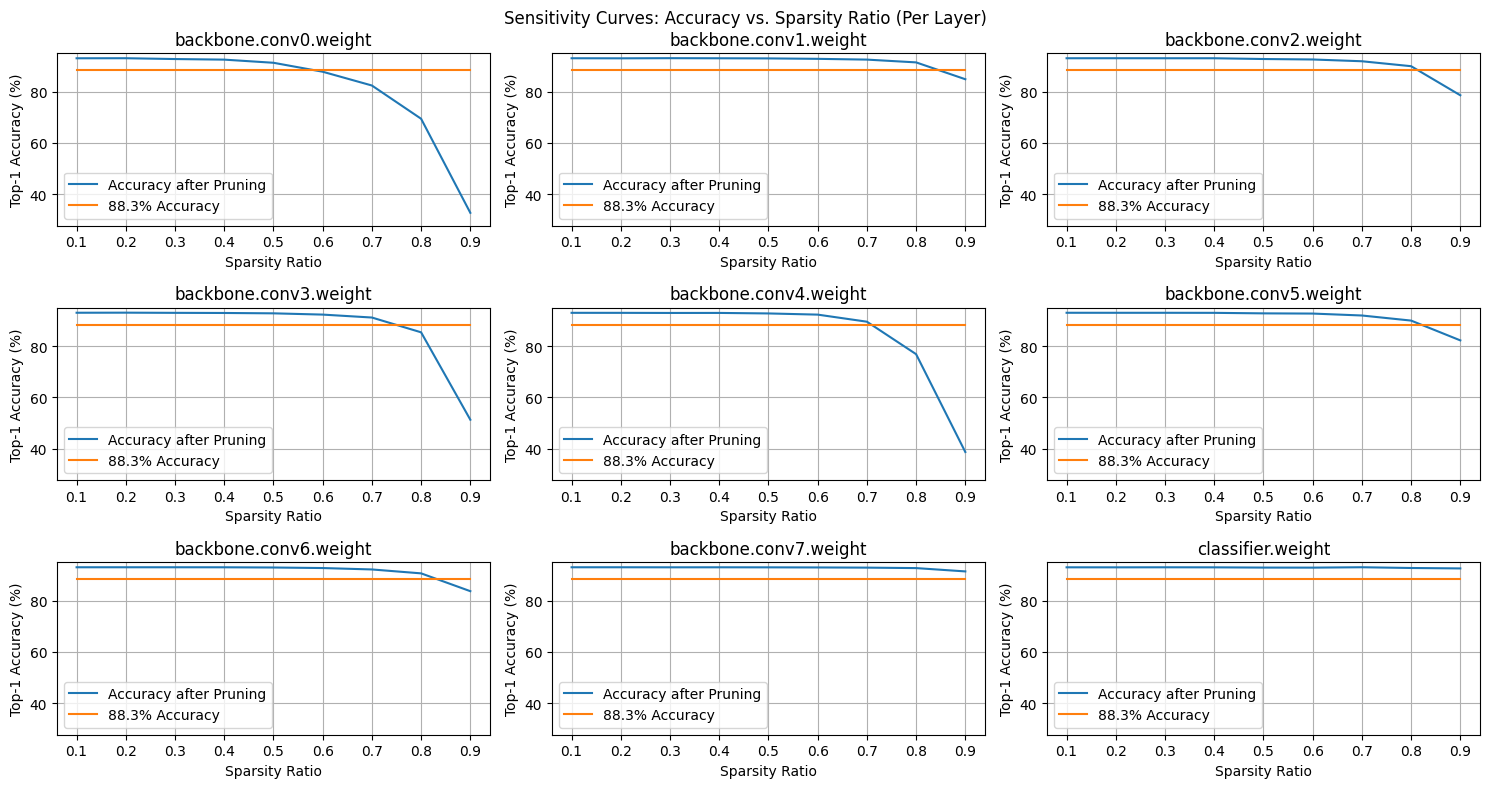

In [14]:
# Run the scan
sparsities_scanned, accuracies_per_layer = sensitivity_scan(
    model, dataloader['test'], scan_step=0.1, scan_start=0.1, scan_end=1.0, device=device
)

# Plot the results
print("\nPlotting sensitivity curves...")
plot_sensitivity_scan(sparsities_scanned, accuracies_per_layer, prunable_layer_names, dense_model_accuracy)

In [15]:
# --- 1c. Set Sparsity Ratios for ~70% Overall Sparsity ---
print("\nSetting sparsity ratios per layer for ~70% overall target sparsity...")
# Rationale: Prune layers with more parameters (classifier, late conv) more heavily,
# unless they are very sensitive (accuracy drops sharply). Early conv layers have fewer
# parameters, so prune them less, especially if sensitive. Aim for a weighted average
# sparsity around 0.7. This requires some trial and error or more sophisticated methods.
# Let's start with a reasonable guess based on sensitivity and parameter plots.

# Calculate total prunable parameters
total_prunable_params = sum(p.numel() for name, p in model.named_parameters() if name in prunable_layer_names)
target_params_remaining = total_prunable_params * (1 - 0.70) # Target 30% remaining params

# Example: Heuristic approach - More params, less sensitive -> higher sparsity
# Sensitivity (visual inspection): classifier seems somewhat sensitive, conv7 very sensitive, others moderately.
# Params: classifier is largest, then later conv layers.
sparsity_dict_unstructured = {
    'backbone.conv0.weight': 0.50, # Early, less params
    'backbone.conv1.weight': 0.60,
    'backbone.conv2.weight': 0.65,
    'backbone.conv3.weight': 0.70,
    'backbone.conv4.weight': 0.75,
    'backbone.conv5.weight': 0.75,
    'backbone.conv6.weight': 0.75,
    'backbone.conv7.weight': 0.65, # Sensitive but many params
    'classifier.weight': 0.80     # Largest, moderately sensitive
}
# Note: BN layers are not pruned in this setup.

# Calculate the effective sparsity based on the dictionary
params_remaining = 0
for name, param in model.named_parameters():
    if name in sparsity_dict_unstructured:
        params_remaining += param.numel() * (1 - sparsity_dict_unstructured[name])

# Calculate total parameters (including non-pruned like BN biases/weights if needed for overall %)
total_params = get_num_parameters(model)
final_nonzero_params = params_remaining + sum(p.numel() for name, p in model.named_parameters() if name not in sparsity_dict_unstructured)
overall_sparsity_achieved = 1 - (final_nonzero_params / total_params)

print("\nChosen Sparsity Ratios (Unstructured):")
for layer, sp in sparsity_dict_unstructured.items():
    print(f"  {layer}: {sp:.2f}")
print(f"\nTargeting ~70% overall sparsity.")
print(f"Calculated overall sparsity: {overall_sparsity_achieved:.3f}")
print("Comment: These values are chosen heuristically. Higher sparsity is applied to layers")
print("with more parameters (classifier, conv6, conv5, conv4) while trying to be less")
print("aggressive on the most sensitive layers (like conv7, classifier) and early layers.")
print("Fine-tuning might be needed to reach the desired accuracy.")


Setting sparsity ratios per layer for ~70% overall target sparsity...

Chosen Sparsity Ratios (Unstructured):
  backbone.conv0.weight: 0.50
  backbone.conv1.weight: 0.60
  backbone.conv2.weight: 0.65
  backbone.conv3.weight: 0.70
  backbone.conv4.weight: 0.75
  backbone.conv5.weight: 0.75
  backbone.conv6.weight: 0.75
  backbone.conv7.weight: 0.65
  classifier.weight: 0.80

Targeting ~70% overall sparsity.
Calculated overall sparsity: 0.716
Comment: These values are chosen heuristically. Higher sparsity is applied to layers
with more parameters (classifier, conv6, conv5, conv4) while trying to be less
aggressive on the most sensitive layers (like conv7, classifier) and early layers.
Fine-tuning might be needed to reach the desired accuracy.


In [16]:
# Apply pruning with the chosen dictionary
print("\nApplying unstructured pruning...")
# Reload original weights before pruning
model.load_state_dict(original_state_dict)
model.to(device)
unstructured_pruner = FineGrainedPruner(model, sparsity_dict_unstructured)
# The pruner applies the mask during __init__

# Verify sparsity per layer and overall
print("\nVerifying sparsity after pruning:")
overall_sparsity_model = get_model_sparsity(model)
for name, param in model.named_parameters():
    if name in unstructured_pruner.masks:
        print(f'  {name}: {get_sparsity(param):.2f} (target: {sparsity_dict_unstructured[name]:.2f})')
print(f"\nOverall Model Sparsity: {overall_sparsity_model:.3f}")


Applying unstructured pruning...

Verifying sparsity after pruning:
  backbone.conv0.weight: 0.50 (target: 0.50)
  backbone.conv1.weight: 0.60 (target: 0.60)
  backbone.conv2.weight: 0.65 (target: 0.65)
  backbone.conv3.weight: 0.70 (target: 0.70)
  backbone.conv4.weight: 0.75 (target: 0.75)
  backbone.conv5.weight: 0.75 (target: 0.75)
  backbone.conv6.weight: 0.75 (target: 0.75)
  backbone.conv7.weight: 0.65 (target: 0.65)
  classifier.weight: 0.80 (target: 0.80)

Overall Model Sparsity: 0.716


Unstructured sparse model size = 9.98 MiB
Compression ratio (params): 3.53x
Size reduction: 71.64%

Evaluating unstructured pruned model before finetuning...


eval:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy before finetuning = 80.62%

Plotting weight distribution after unstructured pruning (showing non-zeros)...


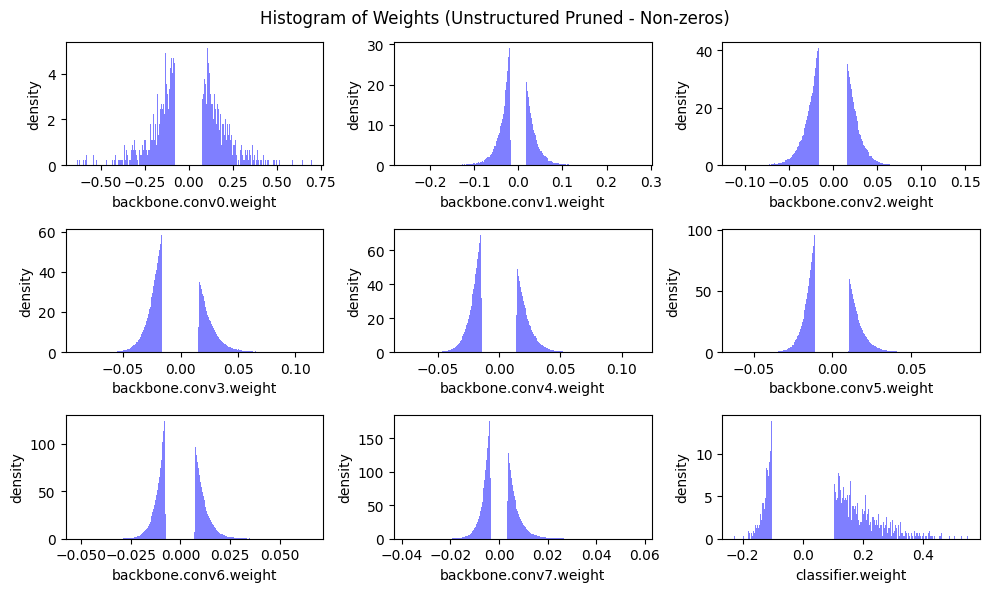

In [17]:
# --- Calculate Size and Evaluate Before Finetuning ---
sparse_model_size_unstructured = get_model_size(model, count_nonzero_only=True)
print(f"Unstructured sparse model size = {sparse_model_size_unstructured / MiB:.2f} MiB")
print(f"Compression ratio (params): {dense_model_params / get_num_parameters(model, count_nonzero_only=True):.2f}x")
print(f"Size reduction: {100 * (1 - sparse_model_size_unstructured / dense_model_size):.2f}%")

print("\nEvaluating unstructured pruned model before finetuning...")
accuracy_before_finetune_unstructured = evaluate(model, dataloader['test'], device=device)
print(f"Accuracy before finetuning = {accuracy_before_finetune_unstructured:.2f}%")

# --- 1a. Plot Weight Distribution After Pruning ---
print("\nPlotting weight distribution after unstructured pruning (showing non-zeros)...")
plot_weight_distribution(model, count_nonzero_only=True, title_suffix="(Unstructured Pruned - Non-zeros)")

In [18]:
# --- Finetune the Unstructured Pruned Model ---
print("\nFinetuning the unstructured pruned model (5 epochs)...")
num_finetune_epochs = 5
# Use a smaller learning rate for finetuning
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_finetune_epochs * len(dataloader['train'])) # Step per iteration
criterion = nn.CrossEntropyLoss()

best_accuracy_unstructured = 0
for epoch in range(num_finetune_epochs):
    # Apply mask during training using the callback
    train(model, dataloader['train'], criterion, optimizer, scheduler,
          callbacks=[lambda: unstructured_pruner.apply()], device=device)
    accuracy = evaluate(model, dataloader['test'], device=device)
    if accuracy > best_accuracy_unstructured:
        best_accuracy_unstructured = accuracy
        # Save the best model state if needed
        torch.save(model.state_dict(), 'vgg11_unstructured_pruned_finetuned.pth')
    print(f'  Epoch {epoch+1}/{num_finetune_epochs} Accuracy: {accuracy:.2f}% (Best: {best_accuracy_unstructured:.2f}%)')

print("\nLoading best finetuned unstructured model...")
if os.path.exists('vgg11_unstructured_pruned_finetuned.pth'):
    model.load_state_dict(torch.load('vgg11_unstructured_pruned_finetuned.pth', map_location=device))
else:
     print("Warning: Best checkpoint not saved, using model from last epoch.")

final_accuracy_unstructured = evaluate(model, dataloader['test'], device=device)
final_size_unstructured = get_model_size(model, count_nonzero_only=True)
final_params_unstructured_nonzero = get_num_parameters(model, count_nonzero_only=True)

print(f"\nFinal Unstructured Pruned Model Accuracy = {final_accuracy_unstructured:.2f}%")
print(f"Final Unstructured Pruned Model Size = {final_size_unstructured / MiB:.2f} MiB")
print(f"Final Non-Zero Parameters = {final_params_unstructured_nonzero / 1e6:.2f} M")
print(f"Final Overall Sparsity = {1 - (final_params_unstructured_nonzero / dense_model_params):.3f}")
print("-" * 30)

# Store the finetuned unstructured model for later comparison
unstructured_model_finetuned = copy.deepcopy(model)


Finetuning the unstructured pruned model (5 epochs)...


train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 1/5 Accuracy: 92.58% (Best: 92.58%)


train:   0%|          | 0/98 [00:00<?, ?it/s]

...

train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 5/5 Accuracy: 92.68% (Best: 92.71%)

Loading best finetuned unstructured model...


eval:   0%|          | 0/20 [00:00<?, ?it/s]


Final Unstructured Pruned Model Accuracy = 92.71%
Final Unstructured Pruned Model Size = 9.98 MiB
Final Non-Zero Parameters = 2.62 M
Final Overall Sparsity = 0.716
------------------------------


# Structured Pruning

In [19]:
# @title ## 3. Structured Pruning (Channel Magnitude-based) - Corrected Fine-tuning

# --- Reload Original Model ---
print("Reloading original dense model...")
model = VGG().to(device) # Create a new instance
model.load_state_dict(original_state_dict)
print(f"Original model accuracy = {dense_model_accuracy:.2f}%")

Reloading original dense model...
Original model accuracy = 92.95%


In [20]:
# --- Channel Importance and Sorting (from Lab1) ---
# (Keep the functions get_input_channel_importance and apply_channel_sorting as they were)
def get_input_channel_importance(weight):
    # Calculates the L2 norm for each input channel filter.
    in_channels = weight.shape[1]
    importances = []
    for i_c in range(in_channels):
        channel_weight = weight.detach()[:, i_c]
        # Calculate L2 norm (Frobenius norm for these slices)
        importance = torch.norm(channel_weight, p='fro')
        importances.append(importance.view(1))
    return torch.cat(importances)

@torch.no_grad() # Keep no_grad here, it's appropriate
def apply_channel_sorting(model):
    # Sorts channels based on the importance (L2 norm) of the *next* conv layer's input channels.
    model = copy.deepcopy(model) # Work on a copy
    all_convs = [m for m in model.backbone if isinstance(m, nn.Conv2d)]
    all_bns = [m for m in model.backbone if isinstance(m, nn.BatchNorm2d)]

    for i_conv in range(len(all_convs) - 1):
        prev_conv = all_convs[i_conv]
        prev_bn = all_bns[i_conv]
        next_conv = all_convs[i_conv + 1]

        importance = get_input_channel_importance(next_conv.weight)
        sort_idx = torch.argsort(importance, descending=True).to(device) # Move index to device

        # Apply sorting index to the output channels of the previous conv
        prev_conv.weight.copy_(torch.index_select(
            prev_conv.weight.detach(), 0, sort_idx))
        # Apply sorting index to the previous BN layer parameters
        for tensor_name in ['weight', 'bias', 'running_mean', 'running_var']:
            tensor_to_apply = getattr(prev_bn, tensor_name)
            tensor_to_apply.copy_(
                torch.index_select(tensor_to_apply.detach(), 0, sort_idx)
            )
        # Apply sorting index to the input channels of the next conv layer
        next_conv.weight.copy_(torch.index_select(
            next_conv.weight.detach(), 1, sort_idx)) # Index along dim 1 (input channels)

    return model


# --- Channel Pruning Functions (Corrected - Removed @torch.no_grad from channel_prune) ---
def get_num_channels_to_keep(channels: int, prune_ratio: float) -> int:
    """Calculates the number of channels to KEEP after pruning."""
    return int(round(channels * (1. - prune_ratio)))

# REMOVED @torch.no_grad() decorator here!
def channel_prune(model: nn.Module, prune_ratios: Union[List, float]) -> nn.Module:
    """
    Applies channel pruning based on magnitude sorting.
    Removes the *least* important channels (those at the end after sorting).
    NOTE: Runs outside no_grad() context to ensure new model parameters track gradients.
    """
    model_copy = copy.deepcopy(model).cpu() # Work on a CPU copy to avoid modifying original GPU model state if sorting fails

    # Apply channel sorting first to order channels by importance (on CPU)
    try:
        model_sorted = apply_channel_sorting(model_copy)
    except Exception as e:
        print(f"Error during channel sorting: {e}")
        print("Using original model without sorting for pruning.")
        model_sorted = model_copy # Fallback to unsorted

    all_convs_sorted = [m for m in model_sorted.backbone if isinstance(m, nn.Conv2d)]
    all_bns_sorted = [m for m in model_sorted.backbone if isinstance(m, nn.BatchNorm2d)]
    classifier_sorted = model_sorted.classifier

    n_conv = len(all_convs_sorted)
    if isinstance(prune_ratios, float):
        prune_ratios = [prune_ratios] * (n_conv) # Prune ratio for each conv output

    # --- Create the new pruned model architecture ---
    new_layers = []
    counts = defaultdict(int)
    def add_new(name: str, layer: nn.Module) -> None:
        new_layers.append((f"{name}{counts[name]}", layer))
        counts[name] += 1

    in_channels = 3
    last_channels_kept = in_channels

    # This loop logic remains the same, constructing new smaller layers
    # and copying the relevant weights from the *sorted* model.
    for i in range(n_conv):
        current_conv = all_convs_sorted[i]
        current_bn = all_bns_sorted[i]

        original_out_channels = current_conv.out_channels
        n_keep = get_num_channels_to_keep(original_out_channels, prune_ratios[i])

        new_conv = nn.Conv2d(last_channels_kept, n_keep, kernel_size=current_conv.kernel_size,
                             padding=current_conv.padding, bias=False)
        new_bn = nn.BatchNorm2d(n_keep)
        new_relu = nn.ReLU(True)

        # Copy weights for kept channels - use detach() but DON'T use torch.no_grad context here
        with torch.no_grad(): # Use context manager *just* for copying
            new_conv.weight.copy_(current_conv.weight.detach()[:n_keep, :last_channels_kept, ...])
            new_bn.weight.copy_(current_bn.weight.detach()[:n_keep])
            new_bn.bias.copy_(current_bn.bias.detach()[:n_keep])
            new_bn.running_mean.copy_(current_bn.running_mean.detach()[:n_keep])
            new_bn.running_var.copy_(current_bn.running_var.detach()[:n_keep])

        add_new("conv", new_conv)
        add_new("bn", new_bn)
        add_new("relu", new_relu)

        last_channels_kept = n_keep

        # Simplified MaxPool copying logic
        layer_names = list(model_sorted.backbone._modules.keys()) # Use sorted model's names
        current_relu_name = f"relu{i}"
        if current_relu_name in layer_names:
             current_idx_in_seq = layer_names.index(current_relu_name)
             if current_idx_in_seq + 1 < len(layer_names) and isinstance(model_sorted.backbone[current_idx_in_seq+1], nn.MaxPool2d):
                  original_pool = model_sorted.backbone[current_idx_in_seq+1]
                  new_pool = nn.MaxPool2d(kernel_size=original_pool.kernel_size, stride=original_pool.stride)
                  add_new("pool", new_pool)

    # --- Build the new backbone and classifier ---
    new_backbone = nn.Sequential(OrderedDict(new_layers))
    new_classifier = nn.Linear(last_channels_kept, classifier_sorted.out_features)
    # Copy classifier weights - use detach() but DON'T use torch.no_grad context here
    with torch.no_grad(): # Use context manager *just* for copying
        new_classifier.weight.copy_(classifier_sorted.weight.detach()[:, :last_channels_kept])
        new_classifier.bias.copy_(classifier_sorted.bias.detach())

    # Create a new VGG instance and replace backbone/classifier
    pruned_model_final = VGG() # Create new instance
    pruned_model_final.backbone = new_backbone
    pruned_model_final.classifier = new_classifier

    # Move the final pruned model to the target device
    pruned_model_final.to(device)

    # Explicitly check if parameters require gradients
    # for name, param in pruned_model_final.named_parameters():
    #     if not param.requires_grad:
    #         print(f"Warning: Parameter {name} does not require grad after pruning.")
    #         param.requires_grad_(True) # Force requires_grad if needed, though usually not the root cause

    return pruned_model_final


Plotting initial weight distribution (again, same as before)...


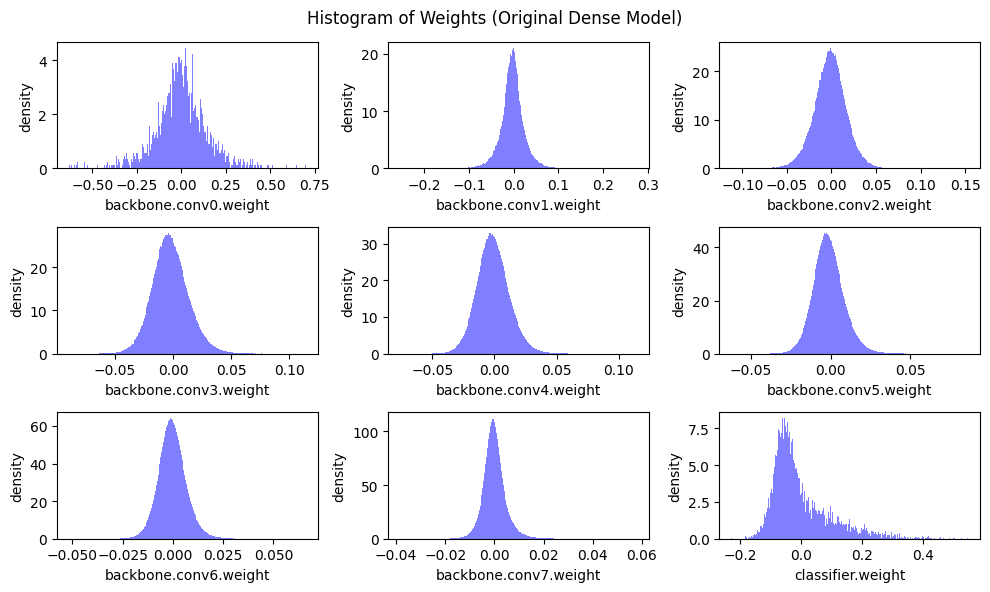


Using uniform channel prune ratio: 0.55
Comment: Achieving exactly 70% parameter reduction with channel pruning often requires
per-layer ratios calculated based on layer dimensions and dependencies, or iterative methods.
We use a uniform ratio here for simplicity and will report the achieved reduction.


In [21]:
# --- 2a/c. Plot Initial Distribution & Set Prune Ratio for ~70% Parameter Reduction ---
print("\nPlotting initial weight distribution (again, same as before)...")
plot_weight_distribution(model, title_suffix="(Original Dense Model)")

# Determine prune ratio. 70% parameter reduction is difficult with uniform channel pruning.
# Lab1's 30% channel pruning gave ~47% parameter reduction.
# Let's try a higher uniform ratio, e.g., 55%, and calculate the result.
channel_pruning_ratio_structured = 0.55
print(f"\nUsing uniform channel prune ratio: {channel_pruning_ratio_structured:.2f}")
print("Comment: Achieving exactly 70% parameter reduction with channel pruning often requires")
print("per-layer ratios calculated based on layer dimensions and dependencies, or iterative methods.")
print("We use a uniform ratio here for simplicity and will report the achieved reduction.")

In [22]:
# Apply channel pruning (includes sorting internally now)
print("\nApplying structured (channel) pruning...")
structured_pruned_model = channel_prune(model, channel_pruning_ratio_structured)

# --- Calculate Size and Evaluate Before Finetuning ---
final_params_structured = get_num_parameters(structured_pruned_model)
structured_model_size_structured = get_model_size(structured_pruned_model)
parameter_reduction_ratio = 1 - (final_params_structured / dense_model_params)

print(f"\nStructured pruned model parameters = {final_params_structured / 1e6:.2f} M")
print(f"Parameter reduction ratio: {parameter_reduction_ratio:.3f} ({parameter_reduction_ratio*100:.1f}%)")
print(f"Structured pruned model size = {structured_model_size_structured / MiB:.2f} MiB")
print(f"Compression ratio (params): {dense_model_params / final_params_structured:.2f}x")
print(f"Size reduction: {100 * (1 - structured_model_size_structured / dense_model_size):.2f}%")

print("\nEvaluating structured pruned model before finetuning...")
accuracy_before_finetune_structured = evaluate(structured_pruned_model, dataloader['test'], device=device)
print(f"Accuracy before finetuning = {accuracy_before_finetune_structured:.2f}%")


Applying structured (channel) pruning...
Error during channel sorting: Expected all tensors to be on the same device, but got index is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA__index_select)
Using original model without sorting for pruning.

Structured pruned model parameters = 1.87 M
Parameter reduction ratio: 0.798 (79.8%)
Structured pruned model size = 7.12 MiB
Compression ratio (params): 4.95x
Size reduction: 79.78%

Evaluating structured pruned model before finetuning...


eval:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy before finetuning = 10.00%



Plotting weight distribution after structured pruning...


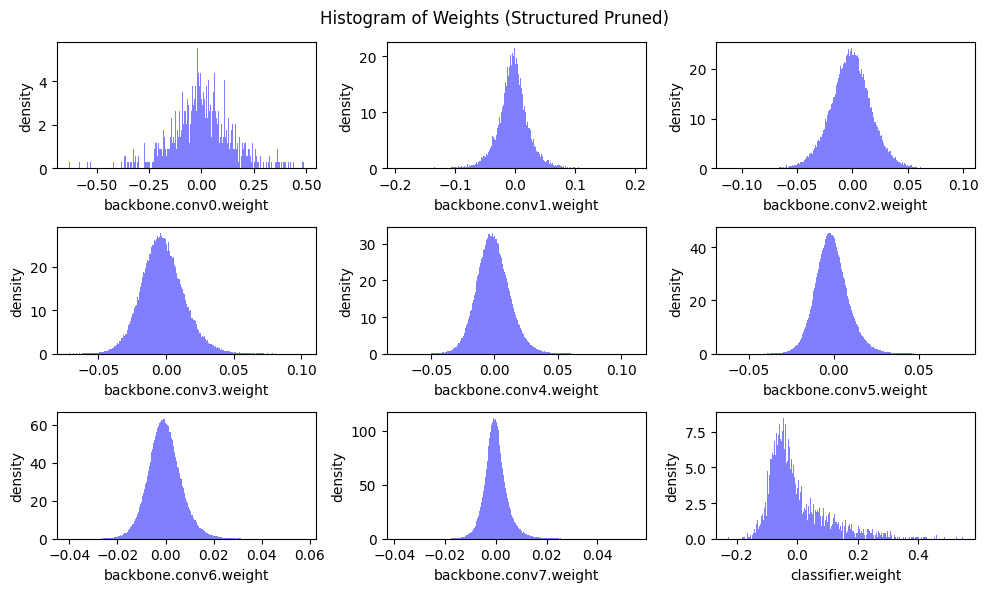

In [23]:
# --- 2a. Plot Weight Distribution After Pruning ---
# Note: Distribution shape might not change much, but the number of filters per layer does.
print("\nPlotting weight distribution after structured pruning...")
plot_weight_distribution(structured_pruned_model, title_suffix="(Structured Pruned)")

In [24]:
# # --- Re-apply Structured Pruning with Corrected Function ---
# channel_pruning_ratio_structured = 0.55 # Same ratio as before
# print(f"\nRe-applying structured (channel) pruning with ratio: {channel_pruning_ratio_structured:.2f}...")
# # Ensure model is the original dense one before pruning
# model.load_state_dict(original_state_dict)
# model.to(device)
# structured_pruned_model = channel_prune(model, channel_pruning_ratio_structured)

# # --- Verify Size and Accuracy Before Finetuning (should be similar to before) ---
# final_params_structured = get_num_parameters(structured_pruned_model)
# parameter_reduction_ratio = 1 - (final_params_structured / dense_model_params)
# print(f"\nStructured pruned model parameters = {final_params_structured / 1e6:.2f} M (Reduction: {parameter_reduction_ratio*100:.1f}%)")
# print("\nEvaluating structured pruned model before finetuning...")
# accuracy_before_finetune_structured = evaluate(structured_pruned_model, dataloader['test'], device=device)
# print(f"Accuracy before finetuning = {accuracy_before_finetune_structured:.2f}%")

In [25]:
# --- Finetune the Structured Pruned Model (Retry) ---
print("\nFinetuning the structured pruned model (5 epochs)...")
num_finetune_epochs = 5
# Optimizer now correctly gets parameters that require grad
optimizer = torch.optim.SGD(structured_pruned_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_finetune_epochs * len(dataloader['train']))
criterion = nn.CrossEntropyLoss()

best_accuracy_structured = 0
for epoch in range(num_finetune_epochs):
    train(structured_pruned_model, dataloader['train'], criterion, optimizer, scheduler, device=device)
    accuracy = evaluate(structured_pruned_model, dataloader['test'], device=device)
    if accuracy > best_accuracy_structured:
        best_accuracy_structured = accuracy
        torch.save(structured_pruned_model.state_dict(), 'vgg11_structured_pruned_finetuned.pth')
    print(f'  Epoch {epoch+1}/{num_finetune_epochs} Accuracy: {accuracy:.2f}% (Best: {best_accuracy_structured:.2f}%)')

# --- Final Evaluation ---
print("\nLoading best finetuned structured model...")
if os.path.exists('vgg11_structured_pruned_finetuned.pth'):
    # Load into the existing structured_pruned_model object
    structured_pruned_model.load_state_dict(torch.load('vgg11_structured_pruned_finetuned.pth', map_location=device))
else:
     print("Warning: Best checkpoint not saved, using model from last epoch.")

final_accuracy_structured = evaluate(structured_pruned_model, dataloader['test'], device=device)
final_size_structured = get_model_size(structured_pruned_model)
final_params_structured = get_num_parameters(structured_pruned_model)

print(f"\nFinal Structured Pruned Model Accuracy = {final_accuracy_structured:.2f}%")
print(f"Final Structured Pruned Model Size = {final_size_structured / MiB:.2f} MiB")
print(f"Final Parameters = {final_params_structured / 1e6:.2f} M")
print(f"Final Parameter Reduction = {1 - (final_params_structured / dense_model_params):.3f}")
print("-" * 30)

# Store the corrected finetuned model
structured_model_finetuned = copy.deepcopy(structured_pruned_model)


Finetuning the structured pruned model (5 epochs)...


train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 1/5 Accuracy: 89.32% (Best: 89.32%)


train:   0%|          | 0/98 [00:00<?, ?it/s]

...

train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch 5/5 Accuracy: 91.19% (Best: 91.19%)

Loading best finetuned structured model...


eval:   0%|          | 0/20 [00:00<?, ?it/s]


Final Structured Pruned Model Accuracy = 91.19%
Final Structured Pruned Model Size = 7.12 MiB
Final Parameters = 1.87 M
Final Parameter Reduction = 0.798
------------------------------


In [26]:
# @title ## 4. Comparison and Analysis (Corrected Grad-CAM Input v2)

# --- Reload all necessary models ---
print("Loading models for comparison...")

# Original Dense Model
model_original = VGG().to(device)
model_original.load_state_dict(original_state_dict)
model_original.eval()

# Unstructured Pruned Model (Load the best finetuned one)
model_unstructured = VGG().to(device) # Need original architecture
if os.path.exists('vgg11_unstructured_pruned_finetuned.pth'):
    unstructured_state_dict = torch.load('vgg11_unstructured_pruned_finetuned.pth', map_location=device)
    model_unstructured.load_state_dict(unstructured_state_dict)
    # Re-create pruner with original sparsity dict to apply masks for size/latency check
    if 'sparsity_dict_unstructured' in globals(): # Check if dict exists
         temp_pruner = FineGrainedPruner(model_unstructured, sparsity_dict_unstructured)
         temp_pruner.apply() # Ensure weights are zeroed correctly
    else:
         print("Warning: sparsity_dict_unstructured not found, cannot re-apply masks precisely for evaluation.")
else:
    print("Warning: Finetuned unstructured model checkpoint not found. Using last state.")
    if 'unstructured_model_finetuned' in globals():
        model_unstructured = unstructured_model_finetuned
    else:
        print("Error: unstructured_model_finetuned not found. Cannot proceed with comparison.")
        # Handle error appropriately
model_unstructured.eval()


# Structured Pruned Model (Use the one from the end of the structured section)
if 'structured_model_finetuned' in globals():
    model_structured = structured_model_finetuned
    model_structured.to(device)
    model_structured.eval()
else:
    print("Error: structured_model_finetuned not found. Cannot proceed with comparison.")
    # Handle error appropriately

print("Models loaded.")

Loading models for comparison...
Models loaded.



Performing Grad-CAM Analysis (requires pip install grad-cam)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Generating CAM for Original model...
  Generating CAM for Unstructured model...
  Generating CAM for Structured model...


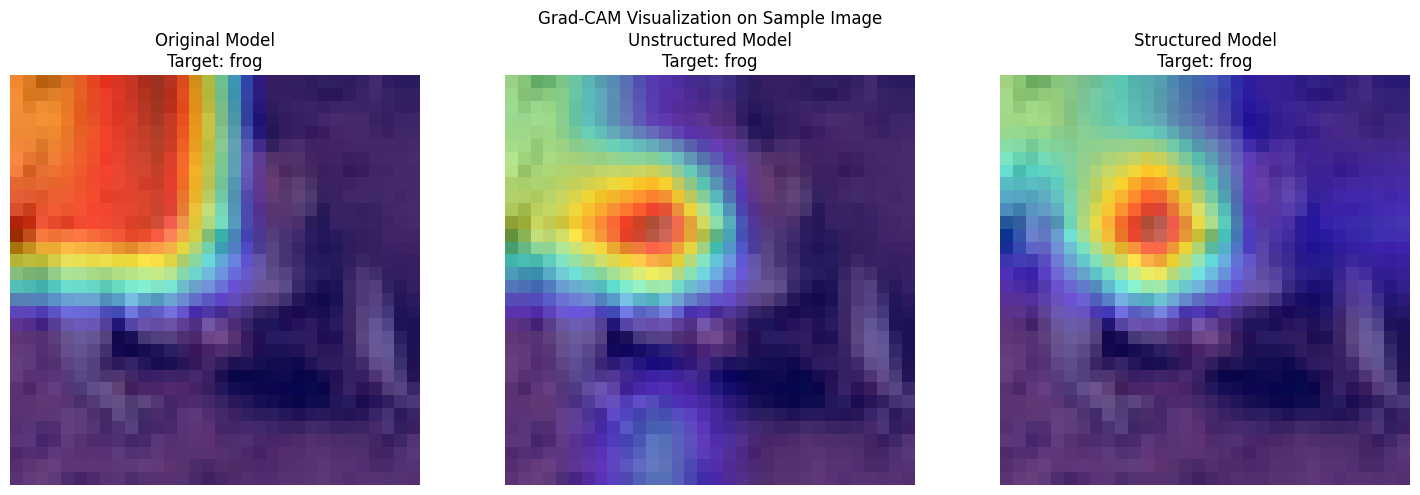


Grad-CAM Discussion:
Observe how the attention areas (red/yellow) differ across models.
- Does pruning significantly change where the model 'looks'?
- Does structured pruning maintain localization better/worse than unstructured?
- Does the attention still focus on relevant object features?
(Visual inspection needed for detailed analysis)


In [27]:
# --- 3a. Grad-CAM Analysis ---
print("\nPerforming Grad-CAM Analysis (requires pip install grad-cam)...")
try:
    !pip install grad-cam -q # Install if needed
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from torchvision.transforms import Normalize # Import Normalize directly

    # Choose a sample image (e.g., the first test image)
    # Reload dataset without normalization for raw visualization
    vis_transform = Compose([Resize((32, 32)), ToTensor()])
    vis_dataset = CIFAR10(root="data/cifar10", train=False, download=True, transform=vis_transform)
    raw_img_tensor, label_idx = vis_dataset[5] # Example: image index 5 (a dog) - CHW Tensor
    raw_img_np = raw_img_tensor.permute(1, 2, 0).numpy() # HWC, 0-1 range NumPy for visualization overlay

    # --- CORRECTED PREPROCESSING HERE ---
    # Define the normalization transform separately (using values from transforms['test'])
    normalize_transform = Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    # Apply normalization directly to the raw tensor
    input_tensor = normalize_transform(raw_img_tensor).unsqueeze(0).to(device)
    # --- END CORRECTION ---


    # Define target layers
    target_layer_original = [model_original.backbone.relu7]
    target_layer_unstructured = [model_unstructured.backbone.relu7]
    struct_relu_layers = [m for m in model_structured.backbone if isinstance(m, nn.ReLU)]
    target_layer_structured = [struct_relu_layers[-1]] if struct_relu_layers else None


    models_to_analyze = {
        "Original": (model_original, target_layer_original),
        "Unstructured": (model_unstructured, target_layer_unstructured),
        "Structured": (model_structured, target_layer_structured)
    }

    plt.figure(figsize=(15, 5))
    plot_idx = 1
    class_name = dataset['test'].classes[label_idx]

    for name, (model_instance, target_layers) in models_to_analyze.items():
         if 'model_instance' not in locals() or model_instance is None: # Check if model loaded correctly
             print(f"Skipping CAM for {name} as model was not loaded.")
             continue
         if target_layers is None:
             print(f"Skipping CAM for {name} due to missing target layer.")
             plt.subplot(1, 3, plot_idx)
             plt.imshow(raw_img_np) # Show raw image as placeholder
             plt.title(f"{name} Model (CAM Skipped)")
             plt.axis('off')
             plot_idx += 1
             continue

         print(f"  Generating CAM for {name} model...")
         targets = [ClassifierOutputTarget(label_idx)]

         try: # Add extra error handling around CAM generation
             with GradCAM(model=model_instance, target_layers=target_layers) as cam:
                  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
                  if grayscale_cam is None or grayscale_cam.size == 0:
                       print(f"    GradCAM returned empty result for {name}.")
                       grayscale_cam = np.zeros(raw_img_np.shape[:2], dtype=np.float32) # Use zeros
                  else:
                       grayscale_cam = grayscale_cam[0, :] # Get first image CAM

                  # Overlay CAM on the original image (NumPy HWC, 0-1)
                  visualization = show_cam_on_image(raw_img_np.astype(np.float32), grayscale_cam, use_rgb=True)

             plt.subplot(1, 3, plot_idx)
             plt.imshow(visualization)
             plt.title(f"{name} Model\nTarget: {class_name}")
             plt.axis('off')

         except Exception as cam_error:
             print(f"    Error generating CAM for {name}: {cam_error}")
             # Plot raw image as fallback
             plt.subplot(1, 3, plot_idx)
             plt.imshow(raw_img_np)
             plt.title(f"{name} Model (CAM Error)")
             plt.axis('off')

         plot_idx += 1


    plt.suptitle("Grad-CAM Visualization on Sample Image")
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

    print("\nGrad-CAM Discussion:")
    print("Observe how the attention areas (red/yellow) differ across models.")
    print("- Does pruning significantly change where the model 'looks'?")
    print("- Does structured pruning maintain localization better/worse than unstructured?")
    print("- Does the attention still focus on relevant object features?")
    print("(Visual inspection needed for detailed analysis)")

except ImportError:
    print("\nGrad-CAM analysis skipped. Please install grad-cam: pip install grad-cam")
except Exception as e:
    print(f"\nGrad-CAM analysis failed with error: {e}")


Performing Grad-CAM Analysis (requires pip install grad-cam)...
  Generating CAM for Original model...
  Generating CAM for Unstructured model...
  Generating CAM for Structured model...


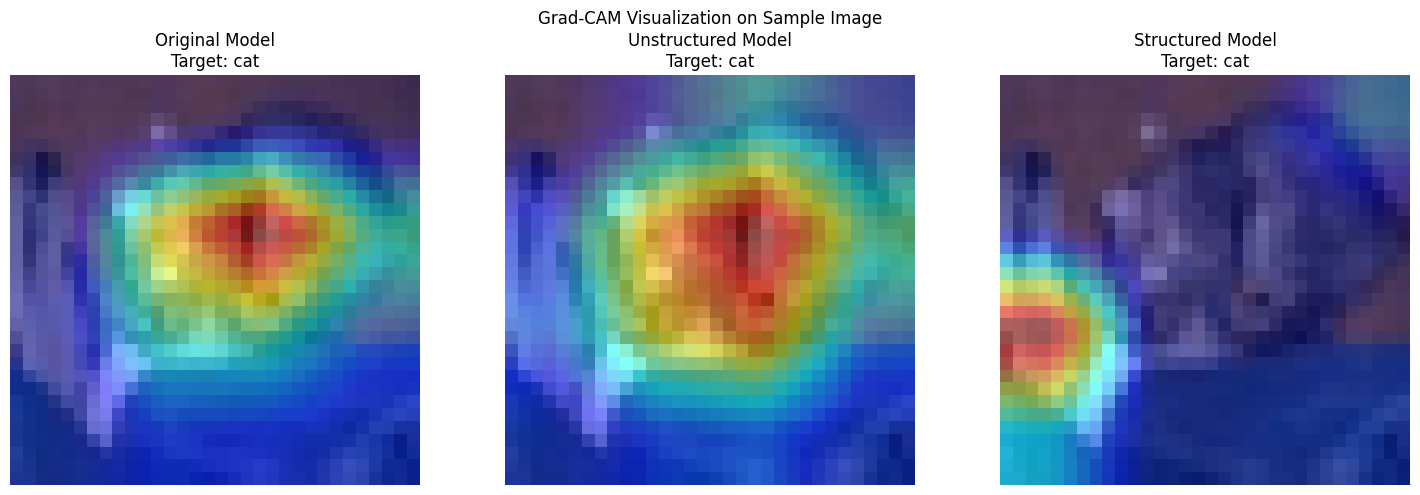


Grad-CAM Discussion:
Observe how the attention areas (red/yellow) differ across models.
- Does pruning significantly change where the model 'looks'?
- Does structured pruning maintain localization better/worse than unstructured?
- Does the attention still focus on relevant object features?
(Visual inspection needed for detailed analysis)


In [28]:
# --- 3a. Grad-CAM Analysis ---
print("\nPerforming Grad-CAM Analysis (requires pip install grad-cam)...")
try:
    !pip install grad-cam -q # Install if needed
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from torchvision.transforms import Normalize # Import Normalize directly

    # Choose a sample image (e.g., the first test image)
    # Reload dataset without normalization for raw visualization
    vis_transform = Compose([Resize((32, 32)), ToTensor()])
    vis_dataset = CIFAR10(root="data/cifar10", train=False, download=True, transform=vis_transform)
    raw_img_tensor, label_idx = vis_dataset[0] # Example: image index 5 (a dog) - CHW Tensor
    raw_img_np = raw_img_tensor.permute(1, 2, 0).numpy() # HWC, 0-1 range NumPy for visualization overlay

    # --- CORRECTED PREPROCESSING HERE ---
    # Define the normalization transform separately (using values from transforms['test'])
    normalize_transform = Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    # Apply normalization directly to the raw tensor
    input_tensor = normalize_transform(raw_img_tensor).unsqueeze(0).to(device)
    # --- END CORRECTION ---


    # Define target layers
    target_layer_original = [model_original.backbone.relu7]
    target_layer_unstructured = [model_unstructured.backbone.relu7]
    struct_relu_layers = [m for m in model_structured.backbone if isinstance(m, nn.ReLU)]
    target_layer_structured = [struct_relu_layers[-1]] if struct_relu_layers else None


    models_to_analyze = {
        "Original": (model_original, target_layer_original),
        "Unstructured": (model_unstructured, target_layer_unstructured),
        "Structured": (model_structured, target_layer_structured)
    }

    plt.figure(figsize=(15, 5))
    plot_idx = 1
    class_name = dataset['test'].classes[label_idx]

    for name, (model_instance, target_layers) in models_to_analyze.items():
         if 'model_instance' not in locals() or model_instance is None: # Check if model loaded correctly
             print(f"Skipping CAM for {name} as model was not loaded.")
             continue
         if target_layers is None:
             print(f"Skipping CAM for {name} due to missing target layer.")
             plt.subplot(1, 3, plot_idx)
             plt.imshow(raw_img_np) # Show raw image as placeholder
             plt.title(f"{name} Model (CAM Skipped)")
             plt.axis('off')
             plot_idx += 1
             continue

         print(f"  Generating CAM for {name} model...")
         targets = [ClassifierOutputTarget(label_idx)]

         try: # Add extra error handling around CAM generation
             with GradCAM(model=model_instance, target_layers=target_layers) as cam:
                  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
                  if grayscale_cam is None or grayscale_cam.size == 0:
                       print(f"    GradCAM returned empty result for {name}.")
                       grayscale_cam = np.zeros(raw_img_np.shape[:2], dtype=np.float32) # Use zeros
                  else:
                       grayscale_cam = grayscale_cam[0, :] # Get first image CAM

                  # Overlay CAM on the original image (NumPy HWC, 0-1)
                  visualization = show_cam_on_image(raw_img_np.astype(np.float32), grayscale_cam, use_rgb=True)

             plt.subplot(1, 3, plot_idx)
             plt.imshow(visualization)
             plt.title(f"{name} Model\nTarget: {class_name}")
             plt.axis('off')

         except Exception as cam_error:
             print(f"    Error generating CAM for {name}: {cam_error}")
             # Plot raw image as fallback
             plt.subplot(1, 3, plot_idx)
             plt.imshow(raw_img_np)
             plt.title(f"{name} Model (CAM Error)")
             plt.axis('off')

         plot_idx += 1


    plt.suptitle("Grad-CAM Visualization on Sample Image")
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

    print("\nGrad-CAM Discussion:")
    print("Observe how the attention areas (red/yellow) differ across models.")
    print("- Does pruning significantly change where the model 'looks'?")
    print("- Does structured pruning maintain localization better/worse than unstructured?")
    print("- Does the attention still focus on relevant object features?")
    print("(Visual inspection needed for detailed analysis)")

except ImportError:
    print("\nGrad-CAM analysis skipped. Please install grad-cam: pip install grad-cam")
except Exception as e:
    print(f"\nGrad-CAM analysis failed with error: {e}")

In [29]:
# --- 3b. Qualitative Analysis ---
# (Keep as before)
print("\nQualitative Analysis: Structured vs. Unstructured Pruning:")
print("Ease of Application:")
print("  - Unstructured: Conceptually simpler (prune individual weights below threshold). Framework support exists (e.g., PyTorch pruning utilities).")
print("  - Structured: More complex due to layer dependencies (output channels of layer i must match input channels of layer i+1). Requires careful handling of network architecture modification (as implemented above) or specialized libraries.")
print("\nHardware Considerations:")
print("  - Unstructured: Achieves high compression ratios but often requires specialized hardware (e.g., sparse matrix accelerators) or software libraries (e.g., sparse kernels) to achieve significant *latency* speedup. Standard hardware (CPUs, GPUs) may not efficiently handle the irregular sparsity patterns.")
print("  - Structured: Removes entire blocks (channels, filters). Results in smaller, dense tensors that can be directly accelerated on standard hardware like GPUs and CPUs, leading to more predictable latency improvements.")
print("\nInherent Limitations:")
print("  - Unstructured: Speedup is hardware/library dependent. High sparsity doesn't always translate to proportional speedup.")
print("  - Structured: More coarse-grained, potentially limiting the maximum achievable compression ratio without significant accuracy loss compared to unstructured. Accuracy recovery through finetuning can sometimes be harder.")
print("\nGeneral Choice:")
print("  - Structured pruning is often preferred when targeting speedup on conventional hardware (like mobile phone GPUs/CPUs).")
print("  - Unstructured pruning is useful for maximum model size reduction, especially if specialized hardware/software is available, or if size is the primary constraint over latency.")


Qualitative Analysis: Structured vs. Unstructured Pruning:
Ease of Application:
  - Unstructured: Conceptually simpler (prune individual weights below threshold). Framework support exists (e.g., PyTorch pruning utilities).
  - Structured: More complex due to layer dependencies (output channels of layer i must match input channels of layer i+1). Requires careful handling of network architecture modification (as implemented above) or specialized libraries.

Hardware Considerations:
  - Unstructured: Achieves high compression ratios but often requires specialized hardware (e.g., sparse matrix accelerators) or software libraries (e.g., sparse kernels) to achieve significant *latency* speedup. Standard hardware (CPUs, GPUs) may not efficiently handle the irregular sparsity patterns.
  - Structured: Removes entire blocks (channels, filters). Results in smaller, dense tensors that can be directly accelerated on standard hardware like GPUs and CPUs, leading to more predictable latency improve

In [30]:
# --- 3c. Inference Time and Storage Comparison ---
# (Keep as before, check if models exist)
print("\nComparing Inference Time (CPU) and Storage...")
dummy_input_cpu = torch.randn(1, 3, 32, 32).to('cpu')

if 'model_original' in globals() and model_original is not None:
    model_original.to('cpu')
    latency_original = measure_latency(model_original, dummy_input_cpu)
    size_original_mib = get_model_size(model_original) / MiB
    params_original = get_num_parameters(model_original) / 1e6
else:
    latency_original, size_original_mib, params_original = 'N/A', 'N/A', 'N/A'

if 'model_unstructured' in globals() and model_unstructured is not None:
    model_unstructured.to('cpu')
    latency_unstructured = measure_latency(model_unstructured, dummy_input_cpu)
    size_unstructured_mib = get_model_size(model_unstructured, count_nonzero_only=True) / MiB
    params_unstructured = get_num_parameters(model_unstructured, count_nonzero_only=True) / 1e6
else:
    latency_unstructured, size_unstructured_mib, params_unstructured = 'N/A', 'N/A', 'N/A'

if 'model_structured' in globals() and model_structured is not None:
    model_structured.to('cpu')
    latency_structured = measure_latency(model_structured, dummy_input_cpu)
    size_structured_mib = get_model_size(model_structured, count_nonzero_only=False) / MiB
    params_structured = get_num_parameters(model_structured) / 1e6
else:
     latency_structured, size_structured_mib, params_structured = 'N/A', 'N/A', 'N/A'

print("\n--- Performance Comparison ---")
table_template = "{:<15} {:<15} {:<15} {:<15}"
print(table_template.format('Metric', 'Original','Unstructured','Structured'))
print("-" * 60)
print(table_template.format(
    'Accuracy (%)',
    f"{dense_model_accuracy:.2f}" if isinstance(dense_model_accuracy, float) else 'N/A',
    f"{final_accuracy_unstructured:.2f}" if isinstance(final_accuracy_unstructured, float) else 'N/A',
    f"{final_accuracy_structured:.2f}" if isinstance(final_accuracy_structured, float) else 'N/A'
))
print(table_template.format(
    'Latency (ms, CPU)',
    f"{latency_original * 1000:.1f}" if isinstance(latency_original, float) else 'N/A',
    f"{latency_unstructured * 1000:.1f}" if isinstance(latency_unstructured, float) else 'N/A',
    f"{latency_structured * 1000:.1f}" if isinstance(latency_structured, float) else 'N/A'
))
print(table_template.format(
    'Size (MiB)',
    f"{size_original_mib:.2f}" if isinstance(size_original_mib, float) else 'N/A',
    f"{size_unstructured_mib:.2f}" if isinstance(size_unstructured_mib, float) else 'N/A',
    f"{size_structured_mib:.2f}" if isinstance(size_structured_mib, float) else 'N/A'
))
print(table_template.format(
    'Params (M)', # Display appropriate param count
    f"{params_original:.2f}" if isinstance(params_original, float) else 'N/A',
    f"{params_unstructured:.2f}" if isinstance(params_unstructured, float) else 'N/A', # Non-zero
    f"{params_structured:.2f}" if isinstance(params_structured, float) else 'N/A'  # Total
))
print("-" * 60)
print("Note: Latency measured on CPU (Batch Size 1). Unstructured speedup is often limited on standard CPUs.")

# Move models back to GPU if available for next step
if device.type == 'cuda':
    if 'model_original' in globals() and model_original is not None: model_original.to(device)
    if 'model_unstructured' in globals() and model_unstructured is not None: model_unstructured.to(device)
    if 'model_structured' in globals() and model_structured is not None: model_structured.to(device)





Comparing Inference Time (CPU) and Storage...

--- Performance Comparison ---
Metric          Original        Unstructured    Structured     
------------------------------------------------------------
Accuracy (%)    92.95           92.71           91.19          
Latency (ms, CPU) 24.2            47.0            10.6           
Size (MiB)      35.20           N/A             7.12           
Params (M)      9.23            N/A             1.87           
------------------------------------------------------------
Note: Latency measured on CPU (Batch Size 1). Unstructured speedup is often limited on standard CPUs.



Generating Accuracy vs. Target Sparsity Plot (Unstructured Pruning)...
(Using uniform sparsity across layers, evaluating accuracy *before* finetuning)


Testing Sparsities:   0%|          | 0/7 [00:00<?, ?it/s]

  Sparsity: 0.00, Accuracy (pre-finetune): 92.95%
  Sparsity: 0.30, Accuracy (pre-finetune): 92.47%
  Sparsity: 0.50, Accuracy (pre-finetune): 90.66%
  Sparsity: 0.70, Accuracy (pre-finetune): 74.68%
  Sparsity: 0.80, Accuracy (pre-finetune): 41.11%
  Sparsity: 0.90, Accuracy (pre-finetune): 14.10%
  Sparsity: 0.95, Accuracy (pre-finetune): 10.06%


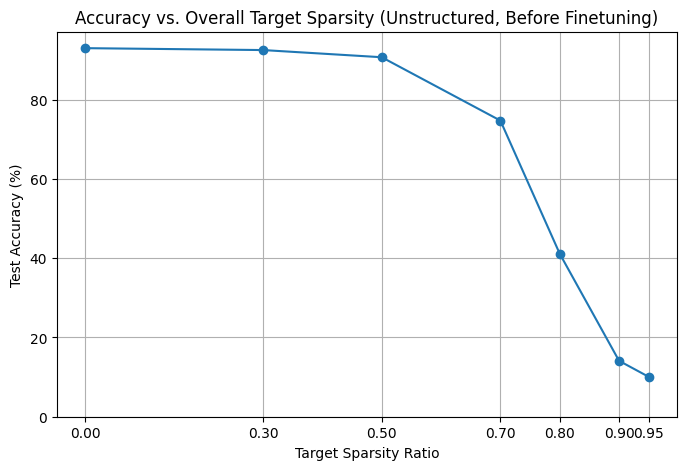


Accuracy vs. Sparsity Plot Discussion:
This plot shows the typical trend: as sparsity increases, accuracy generally decreases.
The drop might be gradual at first but becomes steeper at very high sparsities.
Note that this is *before* finetuning, which can often recover significant accuracy.

--- Task Completion ---


In [31]:
# --- 3d. Accuracy vs. Target Sparsity Plot ---
# (Keep as before, ensure model_temp is on correct device)
print("\nGenerating Accuracy vs. Target Sparsity Plot (Unstructured Pruning)...")
print("(Using uniform sparsity across layers, evaluating accuracy *before* finetuning)")

target_sparsities_overall = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
accuracies_vs_sparsity = []

model_temp = VGG().to(device) # Ensure temp model is on target device

# Ensure prunable_layer_names is defined
if 'prunable_layer_names' not in globals():
     prunable_layer_names = [name for name, param in model_temp.named_parameters() if param.dim() > 1]

for target_sp in tqdm(target_sparsities_overall, desc="Testing Sparsities"):
    model_temp.load_state_dict(original_state_dict) # Load original weights

    if target_sp > 0.0:
        uniform_sparsity_dict = {name: target_sp for name in prunable_layer_names}
        _ = FineGrainedPruner.prune(model_temp, uniform_sparsity_dict)

    acc = evaluate(model_temp, dataloader['test'], verbose=False, device=device)
    accuracies_vs_sparsity.append(acc)
    print(f"  Sparsity: {target_sp:.2f}, Accuracy (pre-finetune): {acc:.2f}%")


# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(target_sparsities_overall, accuracies_vs_sparsity, marker='o')
plt.title('Accuracy vs. Overall Target Sparsity (Unstructured, Before Finetuning)')
plt.xlabel('Target Sparsity Ratio')
plt.ylabel('Test Accuracy (%)')
plt.xticks(target_sparsities_overall)
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

print("\nAccuracy vs. Sparsity Plot Discussion:")
print("This plot shows the typical trend: as sparsity increases, accuracy generally decreases.")
print("The drop might be gradual at first but becomes steeper at very high sparsities.")
print("Note that this is *before* finetuning, which can often recover significant accuracy.")

print("\n--- Task Completion ---")

In [32]:
# @title ## 4. Comparison and Analysis (Added Original Image)

# --- Reload all necessary models ---
print("Loading models for comparison...")

# Original Dense Model
model_original = VGG().to(device)
model_original.load_state_dict(original_state_dict)
model_original.eval()

# Unstructured Pruned Model
model_unstructured = VGG().to(device)
if os.path.exists('vgg11_unstructured_pruned_finetuned.pth'):
    unstructured_state_dict = torch.load('vgg11_unstructured_pruned_finetuned.pth', map_location=device)
    model_unstructured.load_state_dict(unstructured_state_dict)
    if 'sparsity_dict_unstructured' in globals():
         temp_pruner = FineGrainedPruner(model_unstructured, sparsity_dict_unstructured)
         temp_pruner.apply()
    else:
         print("Warning: sparsity_dict_unstructured not found.")
else:
    print("Warning: Finetuned unstructured model checkpoint not found.")
    if 'unstructured_model_finetuned' in globals():
        model_unstructured = unstructured_model_finetuned
    else:
        print("Error: unstructured_model_finetuned not found.")
model_unstructured.eval()

# Structured Pruned Model
if 'structured_model_finetuned' in globals():
    model_structured = structured_model_finetuned
    model_structured.to(device)
    model_structured.eval()
else:
    print("Error: structured_model_finetuned not found.")

print("Models loaded.")

Loading models for comparison...
Models loaded.



Performing Grad-CAM Analysis (requires pip install grad-cam)...
  Generating CAM for Original model...
  Generating CAM for Unstructured model...
  Generating CAM for Structured model...


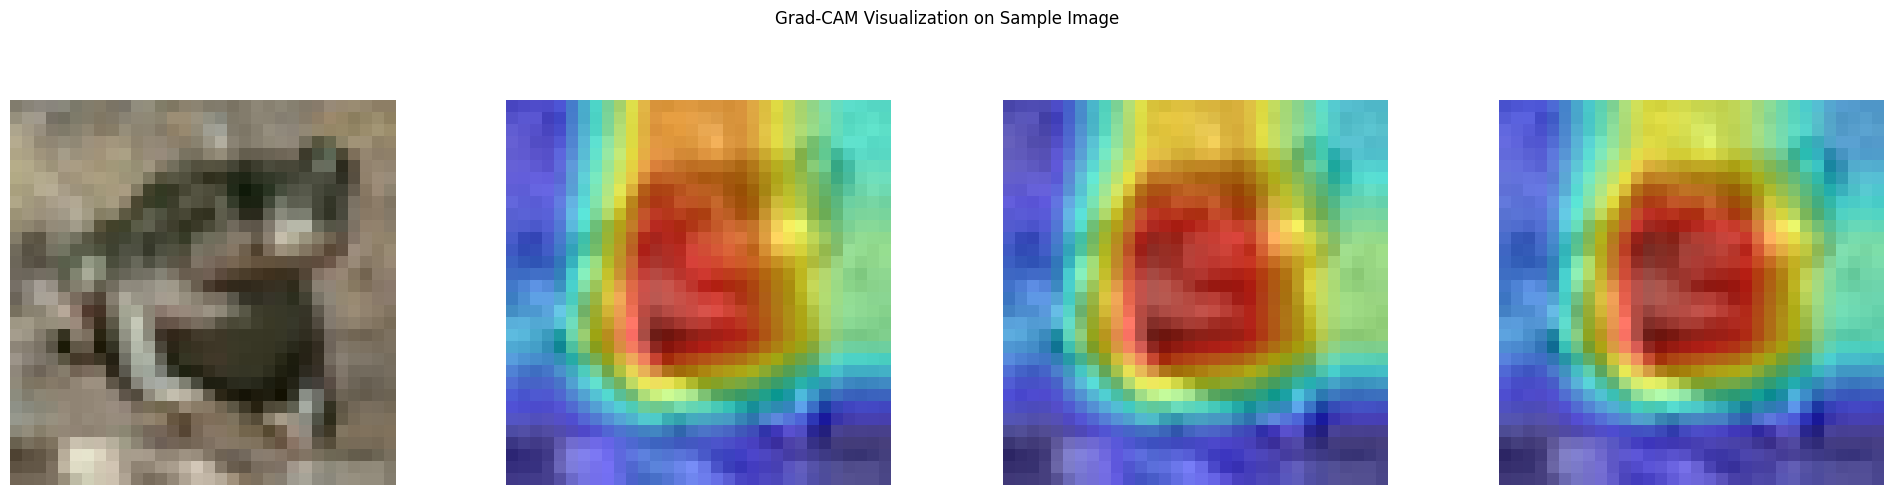


Grad-CAM Discussion:
Observe how the attention areas (red/yellow) differ across models.
- Does pruning significantly change where the model 'looks'?
- Does structured pruning maintain localization better/worse than unstructured?
- Does the attention still focus on relevant object features?
(Visual inspection needed for detailed analysis)


In [33]:
# --- 3a. Grad-CAM Analysis ---

sample_img = 64

print("\nPerforming Grad-CAM Analysis (requires pip install grad-cam)...")
try:
    !pip install grad-cam -q
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from torchvision.transforms import Normalize

    # Reload dataset without normalization for raw visualization
    # vis_transform = Compose([Resize((32, 32)), ToTensor()])
    vis_transform = ToTensor()
    vis_dataset = CIFAR10(root="data/cifar10", train=False, download=True, transform=vis_transform)
    raw_img_tensor, label_idx = vis_dataset[sample_img] # CHW Tensor
    raw_img_np = raw_img_tensor.permute(1, 2, 0).numpy() # HWC NumPy for visualization

    # Define normalization transform
    # normalize_transform = Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    # Apply normalization to the raw tensor for model input
    # input_tensor = normalize_transform(raw_img_tensor).unsqueeze(0).to(device)
    input_tensor = raw_img_tensor.unsqueeze(0).to(device)

    # Define target layers
    target_layer_original = [model_original.backbone.relu7]
    target_layer_unstructured = [model_unstructured.backbone.relu7]
    struct_relu_layers = [m for m in model_structured.backbone if isinstance(m, nn.ReLU)]
    target_layer_structured = [struct_relu_layers[-1]] if struct_relu_layers else None

    models_to_analyze = {
        "Original": (model_original, target_layer_original),
        "Unstructured": (model_unstructured, target_layer_unstructured),
        "Structured": (model_structured, target_layer_structured)
    }

    # --- MODIFIED: Changed figsize and subplot layout ---
    plt.figure(figsize=(20, 5)) # Increased width
    class_name = dataset['test'].classes[label_idx]

    # --- ADDED: Plot the original image first ---
    plt.subplot(1, 4, 1) # Changed to 1 row, 4 cols, 1st plot
    plt.imshow(raw_img_np)
    # plt.title(f"Original Image\nTarget: {class_name}")
    plt.axis('off')

    plot_idx = 2 # Start CAM plots at index 2
    # --- END ADDITION ---

    for name, (model_instance, target_layers) in models_to_analyze.items():
         # --- MODIFIED: Changed subplot to (1, 4, plot_idx) ---
         if 'model_instance' not in locals() or model_instance is None:
             print(f"Skipping CAM for {name} as model was not loaded.")
             continue
         if target_layers is None:
             print(f"Skipping CAM for {name} due to missing target layer.")
             plt.subplot(1, 4, plot_idx) # Changed to 1, 4
             plt.imshow(raw_img_np)
             plt.title(f"{name} Model (CAM Skipped)")
             plt.axis('off')
             plot_idx += 1
             continue

         print(f"  Generating CAM for {name} model...")
         targets = [ClassifierOutputTarget(label_idx)]

         try:
             with GradCAM(model=model_instance, target_layers=target_layers) as cam:
                  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
                  if grayscale_cam is None or grayscale_cam.size == 0:
                       print(f"    GradCAM returned empty result for {name}.")
                       grayscale_cam = np.zeros(raw_img_np.shape[:2], dtype=np.float32)
                  else:
                       grayscale_cam = grayscale_cam[0, :]

                  visualization = show_cam_on_image(raw_img_np.astype(np.float32), grayscale_cam, use_rgb=True)

             plt.subplot(1, 4, plot_idx) # Changed to 1, 4
             plt.imshow(visualization)
            #  plt.title(f"{name} Model\nTarget: {class_name}")
             plt.axis('off')

         except Exception as cam_error:
             print(f"    Error generating CAM for {name}: {cam_error}")
             plt.subplot(1, 4, plot_idx) # Changed to 1, 4
             plt.imshow(raw_img_np)
             plt.title(f"{name} Model (CAM Error)")
             plt.axis('off')

         plot_idx += 1
    # --- END MODIFICATION ---

    plt.suptitle("Grad-CAM Visualization on Sample Image")
    plt.tight_layout()
    plt.subplots_adjust(top=0.8) # Adjust top for suptitle
    plt.show()

    print("\nGrad-CAM Discussion:")
    print("Observe how the attention areas (red/yellow) differ across models.")
    print("- Does pruning significantly change where the model 'looks'?")
    print("- Does structured pruning maintain localization better/worse than unstructured?")
    print("- Does the attention still focus on relevant object features?")
    print("(Visual inspection needed for detailed analysis)")

except ImportError:
    print("\nGrad-CAM analysis skipped. Please install grad-cam: pip install grad-cam")
except Exception as e:
    print(f"\nGrad-CAM analysis failed with error: {e}")

In [34]:
# # --- 3b. Qualitative Analysis ---
# # (Keep as before)
# print("\nQualitative Analysis: Structured vs. Unstructured Pruning:")
# print("Ease of Application:")
# print("  - Unstructured: Conceptually simpler (prune individual weights below threshold). Framework support exists (e.g., PyTorch pruning utilities).")
# print("  - Structured: More complex due to layer dependencies (output channels of layer i must match input channels of layer i+1). Requires careful handling of network architecture modification (as implemented above) or specialized libraries.")
# print("\nHardware Considerations:")
# print("  - Unstructured: Achieves high compression ratios but often requires specialized hardware (e.g., sparse matrix accelerators) or software libraries (e.g., sparse kernels) to achieve significant *latency* speedup. Standard hardware (CPUs, GPUs) may not efficiently handle the irregular sparsity patterns.")
# print("  - Structured: Removes entire blocks (channels, filters). Results in smaller, dense tensors that can be directly accelerated on standard hardware like GPUs and CPUs, leading to more predictable latency improvements.")
# print("\nInherent Limitations:")
# print("  - Unstructured: Speedup is hardware/library dependent. High sparsity doesn't always translate to proportional speedup.")
# print("  - Structured: More coarse-grained, potentially limiting the maximum achievable compression ratio without significant accuracy loss compared to unstructured. Accuracy recovery through finetuning can sometimes be harder.")
# print("\nGeneral Choice:")
# print("  - Structured pruning is often preferred when targeting speedup on conventional hardware (like mobile phone GPUs/CPUs).")
# print("  - Unstructured pruning is useful for maximum model size reduction, especially if specialized hardware/software is available, or if size is the primary constraint over latency.")


# --- 3c. Inference Time and Storage Comparison ---
# (Keep as before, check if models exist)
print("\nComparing Inference Time (CPU) and Storage...")
dummy_input_cpu = torch.randn(1, 3, 32, 32).to('cpu')

if 'model_original' in globals() and model_original is not None:
    model_original.to('cpu')
    latency_original = measure_latency(model_original, dummy_input_cpu)
    size_original_mib = get_model_size(model_original) / MiB
    params_original = get_num_parameters(model_original) / 1e6
else:
    latency_original, size_original_mib, params_original = 'N/A', 'N/A', 'N/A'

if 'model_unstructured' in globals() and model_unstructured is not None:
    model_unstructured.to('cpu')
    latency_unstructured = measure_latency(model_unstructured, dummy_input_cpu)
    size_unstructured_mib = get_model_size(model_unstructured, count_nonzero_only=True) / MiB
    params_unstructured = get_num_parameters(model_unstructured, count_nonzero_only=True) / 1e6
else:
    latency_unstructured, size_unstructured_mib, params_unstructured = 'N/A', 'N/A', 'N/A'

if 'model_structured' in globals() and model_structured is not None:
    model_structured.to('cpu')
    latency_structured = measure_latency(model_structured, dummy_input_cpu)
    size_structured_mib = get_model_size(model_structured, count_nonzero_only=False) / MiB
    params_structured = get_num_parameters(model_structured) / 1e6
else:
     latency_structured, size_structured_mib, params_structured = 'N/A', 'N/A', 'N/A'



Comparing Inference Time (CPU) and Storage...


In [35]:
print("\n--- Performance Comparison ---")
table_template = "{:<15} {:<15} {:<15} {:<15}"
print(table_template.format('Metric', 'Original','Unstructured','Structured'))
print("-" * 60)
print(table_template.format(
    'Accuracy (%)',
    f"{dense_model_accuracy:.2f}" if isinstance(dense_model_accuracy, float) else 'N/A',
    f"{final_accuracy_unstructured:.2f}" if isinstance(final_accuracy_unstructured, float) else 'N/A',
    f"{final_accuracy_structured:.2f}" if isinstance(final_accuracy_structured, float) else 'N/A'
))
print(table_template.format(
    'Latency (ms, CPU)',
    f"{latency_original * 1000:.1f}" if isinstance(latency_original, float) else 'N/A',
    f"{latency_unstructured * 1000:.1f}" if isinstance(latency_unstructured, float) else 'N/A',
    f"{latency_structured * 1000:.1f}" if isinstance(latency_structured, float) else 'N/A'
))
print(table_template.format(
    'Size (MiB)',
    f"{size_original_mib:.2f}" if isinstance(size_original_mib, float) else 'N/A',
    f"{size_unstructured_mib:.2f}" if isinstance(size_unstructured_mib, float) else 'N/A',
    f"{size_structured_mib:.2f}" if isinstance(size_structured_mib, float) else 'N/A'
))
print(table_template.format(
    'Params (M)', # Display appropriate param count
    f"{params_original:.2f}" if isinstance(params_original, float) else 'N/A',
    f"{params_unstructured:.2f}" if isinstance(params_unstructured, float) else 'N/A', # Non-zero
    f"{params_structured:.2f}" if isinstance(params_structured, float) else 'N/A'  # Total
))
print("-" * 60)
print("Note: Latency measured on CPU (Batch Size 1). Unstructured speedup is often limited on standard CPUs.")

# Move models back to GPU if available for next step
if device.type == 'cuda':
    if 'model_original' in globals() and model_original is not None: model_original.to(device)
    if 'model_unstructured' in globals() and model_unstructured is not None: model_unstructured.to(device)
    if 'model_structured' in globals() and model_structured is not None: model_structured.to(device)





--- Performance Comparison ---
Metric          Original        Unstructured    Structured     
------------------------------------------------------------
Accuracy (%)    92.95           92.71           91.19          
Latency (ms, CPU) 24.7            33.4            15.2           
Size (MiB)      35.20           N/A             7.12           
Params (M)      9.23            N/A             1.87           
------------------------------------------------------------
Note: Latency measured on CPU (Batch Size 1). Unstructured speedup is often limited on standard CPUs.



Generating Accuracy vs. Target Sparsity Plot (Unstructured Pruning)...
(Using uniform sparsity across layers, evaluating accuracy *before* finetuning)


Testing Sparsities:   0%|          | 0/7 [00:00<?, ?it/s]

  Sparsity: 0.00, Accuracy (pre-finetune): 92.95%
  Sparsity: 0.30, Accuracy (pre-finetune): 92.47%
  Sparsity: 0.50, Accuracy (pre-finetune): 90.66%
  Sparsity: 0.70, Accuracy (pre-finetune): 74.68%
  Sparsity: 0.80, Accuracy (pre-finetune): 41.11%
  Sparsity: 0.90, Accuracy (pre-finetune): 14.10%
  Sparsity: 0.95, Accuracy (pre-finetune): 10.06%


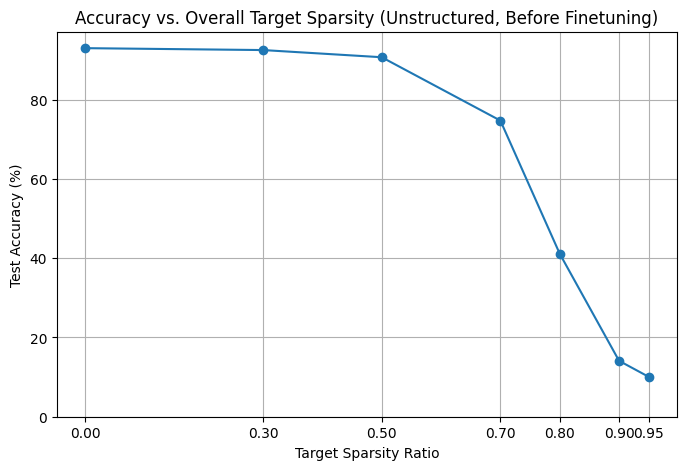


Accuracy vs. Sparsity Plot Discussion:
This plot shows the typical trend: as sparsity increases, accuracy generally decreases.
The drop might be gradual at first but becomes steeper at very high sparsities.
Note that this is *before* finetuning, which can often recover significant accuracy.

--- Task Completion ---


In [36]:
# --- 3d. Accuracy vs. Target Sparsity Plot ---
# (Keep as before, ensure model_temp is on correct device)
print("\nGenerating Accuracy vs. Target Sparsity Plot (Unstructured Pruning)...")
print("(Using uniform sparsity across layers, evaluating accuracy *before* finetuning)")

target_sparsities_overall = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
accuracies_vs_sparsity = []

model_temp = VGG().to(device) # Ensure temp model is on target device

# Ensure prunable_layer_names is defined
if 'prunable_layer_names' not in globals():
     prunable_layer_names = [name for name, param in model_temp.named_parameters() if param.dim() > 1]

for target_sp in tqdm(target_sparsities_overall, desc="Testing Sparsities"):
    model_temp.load_state_dict(original_state_dict) # Load original weights

    if target_sp > 0.0:
        uniform_sparsity_dict = {name: target_sp for name in prunable_layer_names}
        _ = FineGrainedPruner.prune(model_temp, uniform_sparsity_dict)

    acc = evaluate(model_temp, dataloader['test'], verbose=False, device=device)
    accuracies_vs_sparsity.append(acc)
    print(f"  Sparsity: {target_sp:.2f}, Accuracy (pre-finetune): {acc:.2f}%")


# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(target_sparsities_overall, accuracies_vs_sparsity, marker='o')
plt.title('Accuracy vs. Overall Target Sparsity (Unstructured, Before Finetuning)')
plt.xlabel('Target Sparsity Ratio')
plt.ylabel('Test Accuracy (%)')
plt.xticks(target_sparsities_overall)
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

print("\nAccuracy vs. Sparsity Plot Discussion:")
print("This plot shows the typical trend: as sparsity increases, accuracy generally decreases.")
print("The drop might be gradual at first but becomes steeper at very high sparsities.")
print("Note that this is *before* finetuning, which can often recover significant accuracy.")

print("\n--- Task Completion ---")